#Thao tác cơ bản

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import os

# # Đường dẫn gốc của project
# project_root = '/content/drive/MyDrive/Seeding_Recognition_Project'

# # Danh sách thư mục cần tạo
# folders = [
#     'data/dataset_1/raw', 'data/dataset_1/processed',
#     'data/dataset_2/raw', 'data/dataset_2/processed',
#     'data/dataset_3/raw', 'data/dataset_3/processed',
#     'experiments/approach_1/notebooks', 'experiments/approach_1/models', 'experiments/approach_1/results',
#     'experiments/approach_2/notebooks', 'experiments/approach_2/models', 'experiments/approach_2/results',
#     'experiments/approach_3/notebooks', 'experiments/approach_3/models', 'experiments/approach_3/results',
#     'scripts', 'reports/figures'
# ]

# # Tạo thư mục
# for folder in folders:
#     path = os.path.join(project_root, folder)
#     os.makedirs(path, exist_ok=True)

# print("Project folder structure created successfully!")

In [ ]:
import os
DIR_ROOT = '/content/drive/MyDrive/Seeding_Recognition_Project'
DIR_DATASET = os.path.join(DIR_ROOT, 'data/vispamdetection_dataset')

PATH_VI_TRAIN = os.path.join(DIR_DATASET, 'dataset/train.csv')
PATH_VI_DEV = os.path.join(DIR_DATASET, 'dataset/dev.csv')
PATH_VI_TEST = os.path.join(DIR_DATASET, 'dataset/test.csv')

STOPWORDS_PATH = os.path.join(DIR_ROOT, 'vietnamese-stopwords-dash.txt')
EMBEDDING_PATH = os.path.join(DIR_ROOT, 'cc.vi.300.vec')
TOKENIZER_PATH = os.path.join(DIR_ROOT, 'tokenizer.pickle')

MODEL_DIR = os.path.join(DIR_ROOT, 'model')
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

print("Project folder structure created successfully!")

Project folder structure created successfully!


# **Data Understanding**
## 1.1. EDA

In [ ]:
import pandas as pd

data_train = pd.read_csv(PATH_VI_TRAIN)
X_train = data_train.iloc[:, 0:2]
y_train = data_train.iloc[:, 2:4]

data_dev = pd.read_csv(PATH_VI_DEV)
X_dev = data_dev.iloc[:, 0:2]
y_dev = data_dev.iloc[:, 2:4]

data_test = pd.read_csv(PATH_VI_TEST)
X_test = data_test.iloc[:, 0:2]
y_test = data_test.iloc[:, 2:4]

# Kiểm tra thông tin tổng quát
data_train.info()
data_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14306 entries, 0 to 14305
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Rating     14306 non-null  int64 
 1   Comment    14306 non-null  object
 2   Label      14306 non-null  int64 
 3   SpamLabel  14306 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 447.2+ KB


,Rating,Label,SpamLabel
count,14306.000000,14306.000000,14306.000000
mean,4.854956,0.260101,0.677059
std,0.631351,0.438705,1.180525
min,1.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000
50%,5.000000,0.000000,0.000000
75%,5.000000,1.000000,1.000000
max,5.000000,1.000000,3.000000


In [ ]:
# Kiểm tra số lượng mẫu theo nhãn
data_train['Label'].value_counts()

,count
Label,
0,10585
1,3721


In [ ]:
data_train['SpamLabel'].value_counts(dropna=False)

,count
SpamLabel,
0,10585
3,2439
2,1087
1,195


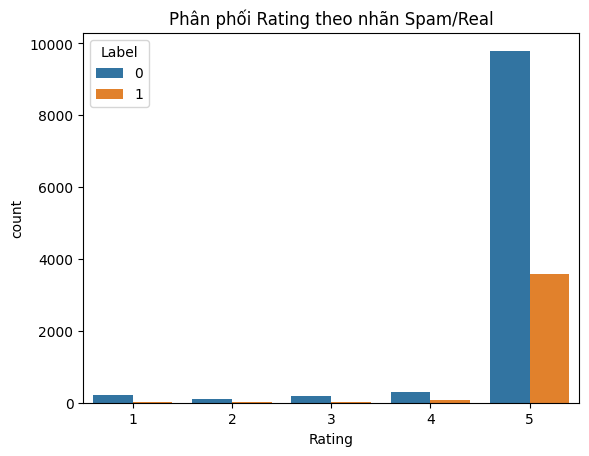

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Phân phối Rating theo từng label
sns.countplot(data=data_train, x='Rating', hue='Label')
plt.title("Phân phối Rating theo nhãn Spam/Real")
plt.show()

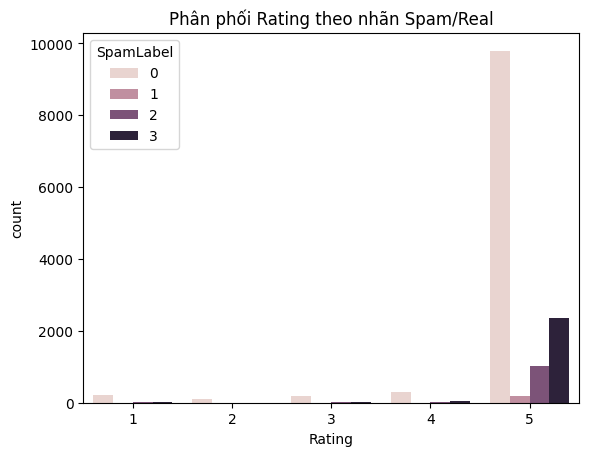

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Phân phối Rating theo từng label
sns.countplot(data=data_train, x='Rating', hue='SpamLabel')
plt.title("Phân phối Rating theo nhãn Spam/Real")
plt.show()

Train Label Distribution:
 SpamLabel
0    10585
1      195
2     1087
3     2439
Name: count, dtype: int64

Dev Label Distribution:
 SpamLabel
0    1157
1      26
2     127
3     280
Name: count, dtype: int64

Test Label Distribution:
 SpamLabel
0    2867
1      61
2     319
3     727
Name: count, dtype: int64


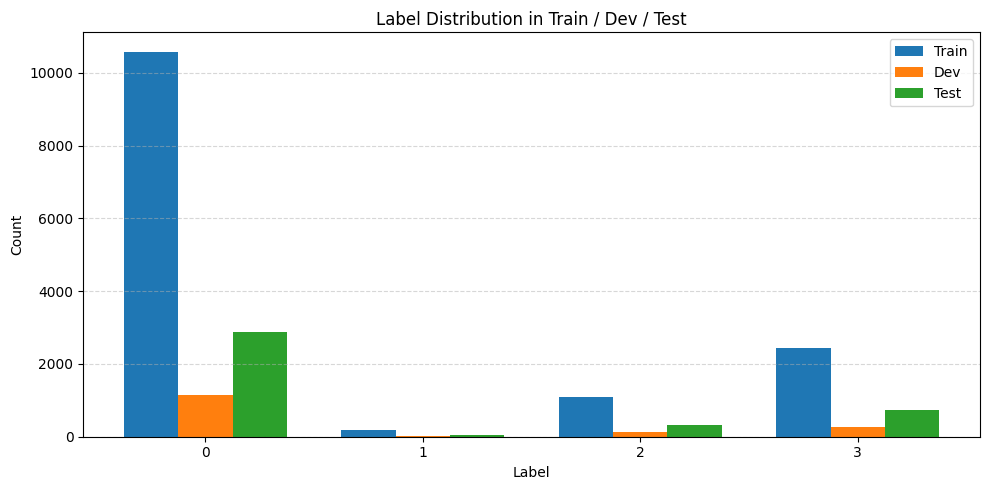

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Đếm số lượng nhãn
train_counts = data_train['SpamLabel'].value_counts().sort_index()
dev_counts   = data_dev['SpamLabel'].value_counts().sort_index()
test_counts  = data_test['SpamLabel'].value_counts().sort_index()

# In bảng phân phối
print("Train Label Distribution:\n", train_counts)
print("\nDev Label Distribution:\n", dev_counts)
print("\nTest Label Distribution:\n", test_counts)

# Vẽ biểu đồ
labels = sorted(list(set(data_train['SpamLabel']) | set(data_dev['SpamLabel']) | set(data_test['SpamLabel'])))

x = range(len(labels))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar([i - width for i in x], train_counts[labels], width=width, label='Train')
plt.bar(x, dev_counts[labels], width=width, label='Dev')
plt.bar([i + width for i in x], test_counts[labels], width=width, label='Test')

plt.xticks(x, labels)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution in Train / Dev / Test")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

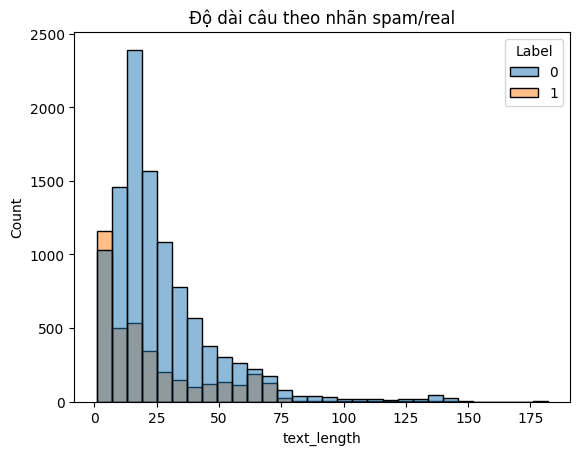

In [ ]:
# Độ dài comment
data_train['text_length'] = data_train['Comment'].apply(lambda x: len(str(x).split()))
sns.histplot(data=data_train, x='text_length', hue='Label', bins=30)
plt.title("Độ dài câu theo nhãn spam/real")
plt.show()

In [ ]:
!wget https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt

--2025-05-09 10:12:29--  https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20475 (20K) [text/plain]
Saving to: ‘vietnamese-stopwords.txt.2’

vietnamese-stopword 100%[===================>]  20.00K  --.-KB/s    in 0.001s  

2025-05-09 10:12:29 (15.3 MB/s) - ‘vietnamese-stopwords.txt.2’ saved [20475/20475]



In [ ]:
! pip install underthesea==6.6.0

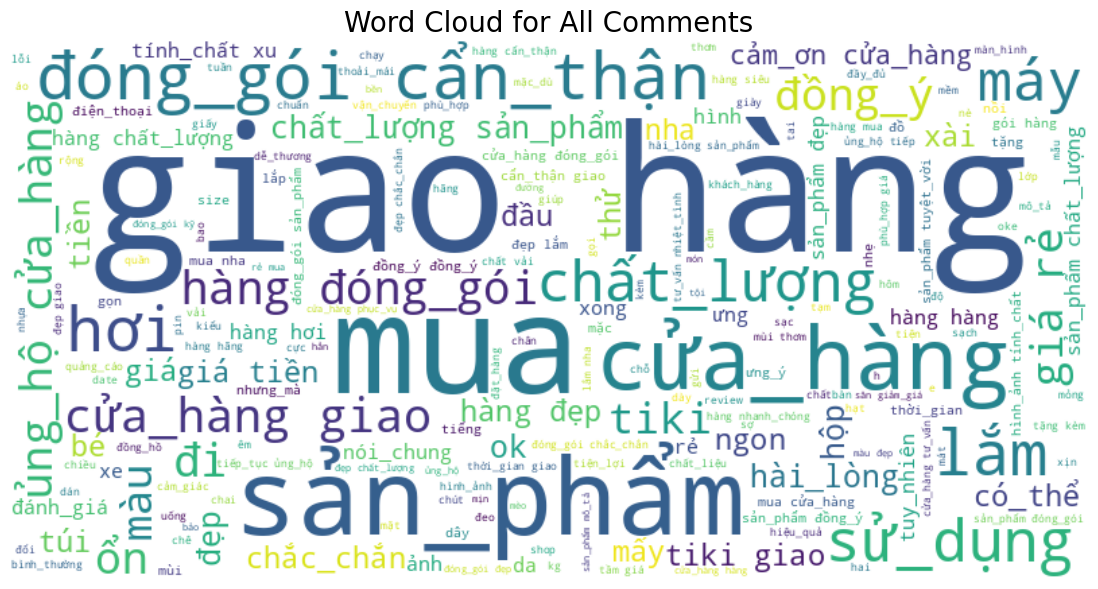

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gộp toàn bộ comment lại thành 1 văn bản
text = ' '.join(X_train_processed.tolist())

# Tạo WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Vẽ WordCloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for All Comments', fontsize=20)
plt.show()


# EDA 2
## Thay đổi Label (giữ spam 1-2 làm thành tố seeding)

In [ ]:
import pandas as pd
import os

# File gốc
files = {
    'train': PATH_VI_TRAIN,
    'dev': PATH_VI_DEV,
    'test': PATH_VI_TEST
}

# Tạo file mới với hậu tố _seeding.csv
for split, path in files.items():
    df = pd.read_csv(path)

    # Tạo lại nhãn seeding
    df['Label'] = df['SpamLabel'].apply(lambda x: 1 if x in [1, 2] else 0)

    # Xoá cột SpamLabel
    df = df.drop(columns=['SpamLabel'])

    # Tạo tên file mới
    new_filename = path.replace('.csv', '_seeding.csv')

    # Ghi file mới
    df.to_csv(new_filename, index=False)
    print(f"✅ Đã tạo file mới: {new_filename}")


✅ Đã tạo file mới: /content/drive/MyDrive/Seeding_Recognition_Project/data/vispamdetection_dataset/dataset/train_seeding.csv
✅ Đã tạo file mới: /content/drive/MyDrive/Seeding_Recognition_Project/data/vispamdetection_dataset/dataset/dev_seeding.csv
✅ Đã tạo file mới: /content/drive/MyDrive/Seeding_Recognition_Project/data/vispamdetection_dataset/dataset/test_seeding.csv


In [ ]:
# Cập nhật đường dẫn đến file mới
PATH_VI_TRAIN_SEEDING = os.path.join(DIR_DATASET, 'dataset/train_seeding.csv')
PATH_VI_DEV_SEEDING = os.path.join(DIR_DATASET, 'dataset/dev_seeding.csv')
PATH_VI_TEST_SEEDING = os.path.join(DIR_DATASET, 'dataset/test_seeding.csv')

# Đọc dữ liệu mới
data_train = pd.read_csv(PATH_VI_TRAIN_SEEDING)
X_train = data_train.iloc[:, 0:2]  #cột 0 là rating, cột 1 là comment
y_train = data_train['Label']

data_dev = pd.read_csv(PATH_VI_DEV_SEEDING)
X_dev = data_dev.iloc[:, 0:2]
y_dev = data_dev['Label']

data_test = pd.read_csv(PATH_VI_TEST_SEEDING)
X_test = data_test.iloc[:, 0:2]
y_test = data_test['Label']

# Kiểm tra thông tin tổng quát
data_train.info()
data_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14306 entries, 0 to 14305
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Rating   14306 non-null  int64 
 1   Comment  14306 non-null  object
 2   Label    14306 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 335.4+ KB


,Rating,Label
count,14306.000000,14306.000000
mean,4.854956,0.089613
std,0.631351,0.285636
min,1.000000,0.000000
25%,5.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,5.000000,1.000000


In [ ]:
# Kiểm tra số lượng mẫu theo nhãn
data_train['Label'].value_counts()

,count
Label,
0,13024
1,1282


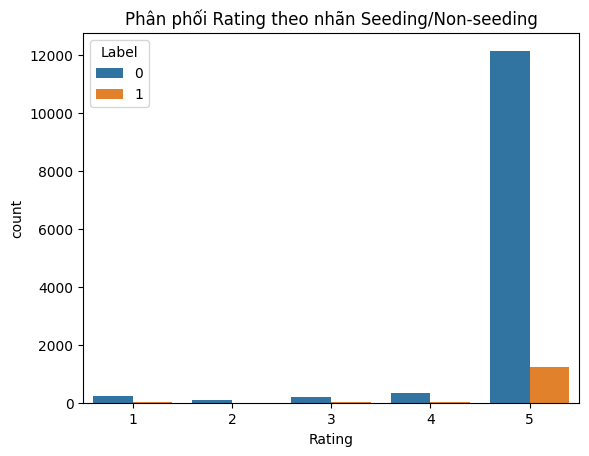

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Phân phối Rating theo từng label
sns.countplot(data=data_train, x='Rating', hue='Label')
plt.title("Phân phối Rating theo nhãn Seeding/Non-seeding")
plt.show()

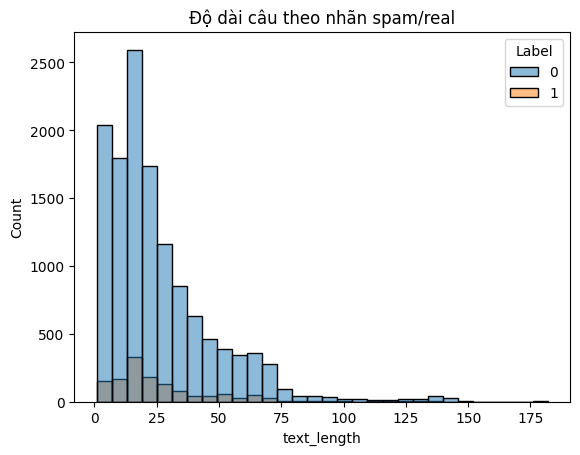

In [ ]:
# Độ dài comment
data_train['text_length'] = data_train['Comment'].apply(lambda x: len(str(x).split()))
sns.histplot(data=data_train, x='text_length', hue='Label', bins=30)
plt.title("Độ dài câu theo nhãn spam/real")
plt.show()

In [ ]:
# Dictionary từ viết tắt phổ biến
abbreviation_dict = {
    "fb": "facebook",
    "ib": "inbox",
    "inb": "inbox",
    "add": "thêm",
    "rep": "trả lời",
    "km": "khuyến mãi",
    "săn sale": "săn giảm giá",
    "sz": "size",
    "ship": "giao hàng",
    "fback": "feedback",
    "lh": "liên hệ",
    "dc": "địa chỉ",
    "hn": "hà nội",
    "hcm": "hồ chí minh",
    "cs1": "cơ sở 1",
    "cs2": "cơ sở 2",
    "oder": "đặt hàng",
    "ib liền": "inbox ngay",
    "sd": "sử dụng",
    "m": "mình",
    "mik": "mình",
    "vs": "với",
    "k": "không",
    "ko": "không",
    "hok": "không",
    "j": "gì",
    "bt": "bình thường",
    "in4": "thông tin",
    "ad": "quảng cáo",
    "shop": "cửa hàng",
    "sale": "giảm giá",
    "km": "khuyến mãi",
    "tv": "tư vấn",
    "sz": "size",
    "ship": "giao hàng",
    "freeship": "miễn phí vận chuyển",
    "sỉ": "bán sỉ",
    "lẻ": "bán lẻ",
    "mn": "mọi người",
    "mik": "mình",
    "mìnhk": "mình",
    "vs": "với",
    "dc": "được",
    "đc": "được",
    "ck": "chuyển khoản",
    "nv": "nhân viên",
    "kh": "khách hàng",
    "sp": "sản phẩm",
    "ql": "quản lý",
    "hn": "hà nội",
    "hcm": "hồ chí minh",
    "sg": "sài gòn",
    "nt": "nhắn tin",
    "tt": "thanh toán",
    "bh": "bảo hành",
    "dt": "điện thoại",
    "tl": "trả lời",
    "tk": "tài khoản",
    "mk": "mật khẩu",
    "vc": "vận chuyển",
    "đt": "điện thoại",
    "đn": "đà nẵng",
    "tn": "tin nhắn",
    "tks": "cảm ơn",
    "thanks": "cảm ơn",
    "okie": "ok",
    "ok": "đồng ý",
    "r": "rồi",
    "rùi": "rồi",
    "z": "vậy",
    "chốt": "đặt hàng",
    "pp": "phương pháp",
    "tg": "thời gian",
    "nsx": "nhà sản xuất",
    "hđ": "hoạt động",
}


def expand_abbreviations(text):
    words = text.split()
    expanded_words = [abbreviation_dict.get(word.lower(), word) for word in words]
    return ' '.join(expanded_words)

In [ ]:
! pip install underthesea==6.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.2 MB/s eta 0:00:00


In [ ]:
!wget https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt

--2025-05-20 19:27:15--  https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20475 (20K) [text/plain]
Saving to: ‘vietnamese-stopwords.txt’

vietnamese-stopword 100%[===================>]  20.00K  --.-KB/s    in 0.002s  

2025-05-20 19:27:15 (12.0 MB/s) - ‘vietnamese-stopwords.txt’ saved [20475/20475]



In [ ]:
import re
import numpy as np
from underthesea import word_tokenize
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

def remove_emoji(text):
    pattern = re.compile("["
                         u"\U0001F600-\U0001F64F"
                         u"\U0001F300-\U0001F5FF"
                         u"\U0001F680-\U0001F6FF"
                         u"\U0001F1E0-\U0001F1FF"
                         "]+", flags=re.UNICODE)
    return pattern.sub(r'', text)

# Tải stopword
with open("vietnamese-stopwords.txt", encoding='utf-8') as f:
    stopwords = set([line.strip() for line in f.readlines()])

def filter_stop_words(sentence):
    return ' '.join([word for word in sentence.split() if word not in stopwords])

def preprocess_text(text):
    text = str(text).lower()
    text = expand_abbreviations(text)
    text = remove_emoji(text)
    text = re.sub(r'[^\w\s]', '', text)  # bỏ ký tự đặc biệt
    text = word_tokenize(text, format="text")
    text = filter_stop_words(text)
    return text

def preprocess_dataset(X, y_label_col="Label"):
    X_processed = X["Comment"].apply(preprocess_text)
    y1 = y_label_col
    return X_processed, y1

# Tiền xử lý cho train/dev/test
X_train_processed = X_train["Comment"].apply(preprocess_text)
X_dev_processed = X_dev["Comment"].apply(preprocess_text)
X_test_processed = X_test["Comment"].apply(preprocess_text)

In [ ]:
X_train

,Rating,Comment
0,5,"Chất lượng sản phẩm tuyệt vời, má"
1,5,Jdjd is a waste of my time and place to ask qu...
2,5,Dhnxncbcncncncncnncncncnncncncncncncncnncncncj...
3,5,"giao hàng nhanh, đóng gói cẩn thận, sản phẩm n..."
4,3,Bạt mỏng vs lại không có túi đi kèm để cất khi...
...,...,...
14301,5,"After the busy days in the city, what I like t..."
14302,5,"Shop giao hàng nhanh, thuốc diệt kiến hiệu quả..."
14303,5,Sh tư vấn nhiệt tình. \nGiao hàng nhanh chóng....
14304,5,"rất hài lòng, giầy đẹp, đi êm chân, giá rẻ, đó..."


In [ ]:
X_train_processed

,Comment
0,chất_lượng sản_phẩm tuyệt_vời má
1,jdjd is a_waste of_my time_and place to ask qu...
2,dhnxncbcncncncncnncncncnncncncncncncncnncncncj...
3,giao hàng đóng_gói cẩn_thận sản_phẩm nói_chung ok
4,bạt mỏng với_lại túi đi kèm cất tạm phù_hợp gi...
...,...
14301,after the busy days in the city what i like th...
14302,cửa_hàng giao hàng thuốc diệt_kiến hiệu_quả ki...
14303,sh tư_vấn nhiệt_tình giao hàng nhanh_chóng sản...
14304,hài_lòng giầy đẹp đi êm chân_giá rẻ đóng_gói c...


In [ ]:
df_train = pd.concat([X_train_processed,
                      y_train], axis=1)


In [ ]:
df_train.head(10)

,Comment,Label
0,chất_lượng sản_phẩm tuyệt_vời má,0
1,jdjd is a_waste of_my time_and place to ask qu...,0
2,dhnxncbcncncncncnncncncnncncncncncncncnncncncj...,0
3,giao hàng đóng_gói cẩn_thận sản_phẩm nói_chung ok,0
4,bạt mỏng với_lại túi đi kèm cất tạm phù_hợp gi...,0
5,đo size hướng_dẫn cửa_hàng trật đổi,0
6,nói_chung ổn sắc nét máy bình_thường in nhiệt ...,0
7,hàng y_hình chất_lượng thế_nào giao hàng,1
8,cửa_hàng giao hàng tư_vấn nhiệt_tình lắm lun g...,0
9,hot hot bánh_tráng trộn_zozo có_mặt gia_lai 25...,0


In [ ]:
import numpy as np
import pandas as pd
import random

# Lọc lớp cần oversample (ví dụ Label == 1)
df_seeding = df_train[df_train['Label'] == 1].copy()

# Tính độ dài (số từ) mỗi văn bản
df_seeding['length'] = df_seeding['Comment'].apply(lambda x: len(x.split()))

# Tạo bins độ dài để gom nhóm (giảm phân tán)
bins = [0, 5, 10, 15, 20, 30, 50, 70, 100]
df_seeding['length_bin'] = pd.cut(df_seeding['length'], bins=bins)

# Tính phân phối theo nhóm độ dài (bin)
bin_distribution = df_seeding['length_bin'].value_counts(normalize=True)
bin_distribution = bin_distribution.sort_index()

# Số mẫu cần sinh thêm (ví dụ gấp 3 lần hiện tại)
num_new_samples = len(df_seeding) * 3

synthetic_texts = []

for _ in range(num_new_samples):
    # Chọn ngẫu nhiên một nhóm độ dài theo phân phối
    target_bin = np.random.choice(bin_distribution.index, p=bin_distribution.values)

    # Lọc các văn bản trong nhóm đó
    candidates = df_seeding[df_seeding['length_bin'] == target_bin]

    if len(candidates) < 2:
        continue  # bỏ qua nếu không đủ mẫu để tổ hợp

    # Chọn 1–2 văn bản ngẫu nhiên
    n_sample = min(len(candidates), random.randint(1, 2))
    selected_docs = candidates.sample(n=n_sample)['Comment'].tolist()

    # Gộp các từ lại
    token_pool = []
    for doc in selected_docs:
        token_pool.extend(doc.split())

    # Sinh câu mới từ token_pool (dài bằng độ dài trung bình của nhóm)
    avg_length = int(candidates['length'].mean())
    synthetic_tokens = random.sample(token_pool, min(avg_length, len(token_pool)))
    synthetic_text = ' '.join(synthetic_tokens)

    synthetic_texts.append(synthetic_text)

# Tạo DataFrame chứa các mẫu sinh ra
synthetic_df = pd.DataFrame({'Comment': synthetic_texts, 'Label': 1})


# Gộp lại với dữ liệu ban đầu
augmented_df = pd.concat([df_train, synthetic_df], ignore_index=True)


In [ ]:
augmented_df

,Comment,Label
0,chất_lượng sản_phẩm tuyệt_vời má,0
1,jdjd is a_waste of_my time_and place to ask qu...,0
2,dhnxncbcncncncncnncncncnncncncncncncncnncncncj...,0
3,giao hàng đóng_gói cẩn_thận sản_phẩm nói_chung ok,0
4,bạt mỏng với_lại túi đi kèm cất tạm phù_hợp gi...,0
...,...,...
18147,tiki wa,1
18148,tem_tag hàng giao đầy_đủ kĩ đóng_gói sử_dụng,1
18149,đồng_ý hàng giao,1
18150,ak ghi 67 chạy ôn_thi mật_khẩu cửa_hàng mua rẻ...,1


In [ ]:
X_train_aug = augmented_df['Comment']
y_train_aug = augmented_df['Label']

In [ ]:
X_train_aug

,Comment
0,chất_lượng sản_phẩm tuyệt_vời má
1,jdjd is a_waste of_my time_and place to ask qu...
2,dhnxncbcncncncncnncncncnncncncncncncncnncncncj...
3,giao hàng đóng_gói cẩn_thận sản_phẩm nói_chung ok
4,bạt mỏng với_lại túi đi kèm cất tạm phù_hợp gi...
...,...
18147,hàng tuyệt_vời cẩn_thận chuẩn_bị siêu hàng đón...
18148,gian thoi giao
18149,chu_đáo hài_lòng hàng
18150,chăm chất mong tn flash học 1 to tặng lg hàng quà


In [ ]:
X_train_aug = X_train_aug.dropna().astype(str).tolist()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

# Khởi tạo tokenizer
MAX_NUM_WORDS = 20000  # số lượng từ tối đa
MAX_SEQUENCE_LENGTH = 100  # độ dài tối đa cho mỗi văn bản

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=False)
tokenizer.fit_on_texts(X_train_aug)

# Lưu tokenizer để tái sử dụng sau này
with open(TOKENIZER_PATH, 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Mã hóa và padding
X_train_seq = tokenizer.texts_to_sequences(X_train_aug)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

X_dev_seq = tokenizer.texts_to_sequences(X_dev_processed)
X_dev_pad = pad_sequences(X_dev_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

X_test_seq = tokenizer.texts_to_sequences(X_test_processed)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

In [ ]:
y_train_aug = y_train_aug.fillna(0).astype(int)

In [ ]:
# Chuẩn hóa nhãn
y_train_label = to_categorical(y_train_aug, num_classes=2)
y_dev_label = to_categorical(y_dev, num_classes=2)
y_test_label = to_categorical(y_test, num_classes=2)

In [ ]:
y_train_label

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [ ]:
# Tải file embedding FastText (.vec)
embedding_index = {}
with open(EMBEDDING_PATH, 'r', encoding='utf-8') as f:
    next(f)  # bỏ dòng đầu (chứa vocab_size và dim)
    for line in f:
        values = line.rstrip().split(' ')
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Tạo embedding matrix khớp với tokenizer
EMBEDDING_DIM = 300  # FastText Việt có 300 chiều
word_index = tokenizer.word_index
num_words = min(MAX_NUM_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
for word, i in word_index.items():
    if i >= MAX_NUM_WORDS:
        continue
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector


In [ ]:
print("Số lượng từ trong tokenizer:", len(tokenizer.word_index))
print("Kích thước X_train_pad:", X_train_pad.shape)
print("Embedding matrix shape:", embedding_matrix.shape)


Số lượng từ trong tokenizer: 13504
Kích thước X_train_pad: (18152, 100)
Embedding matrix shape: (13505, 300)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=10000)
X_train_vec = tfidf.fit_transform(X_train_aug)
X_dev_vec = tfidf.transform(X_dev_processed)
X_test_vec = tfidf.transform(X_test_processed)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

lr = LogisticRegression(class_weight='balanced', solver='liblinear')
grid_lr = GridSearchCV(lr, param_grid_lr, scoring='f1_macro', cv=5)
grid_lr.fit(X_train_vec, y_train_aug)

best_lr = grid_lr.best_estimator_

In [ ]:
from sklearn.naive_bayes import MultinomialNB

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0]
}

nb = MultinomialNB()
grid_nb = GridSearchCV(nb, param_grid_nb, scoring='f1_macro', cv=5)
grid_nb.fit(X_train_vec, y_train_aug)

best_nb = grid_nb.best_estimator_

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1,10]
}

linear_svc = LinearSVC(class_weight='balanced', max_iter=10000)
grid = GridSearchCV(linear_svc, param_grid, scoring='f1_macro', cv=5, verbose=1)
grid.fit(X_train_vec, y_train_aug)

best_svm = grid.best_estimator_

Fitting 5 folds for each of 3 candidates, totalling 15 fits


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))

evaluate_model(best_lr, X_test_vec, y_test, "Logistic Regression")
evaluate_model(best_nb, X_test_vec, y_test, "Naive Bayes")
evaluate_model(best_svm, X_test_vec, y_test, "SVM")


=== Logistic Regression ===
[[3239  355]
 [ 170  210]]
              precision    recall  f1-score   support

           0     0.9501    0.9012    0.9250      3594
           1     0.3717    0.5526    0.4444       380

    accuracy                         0.8679      3974
   macro avg     0.6609    0.7269    0.6847      3974
weighted avg     0.8948    0.8679    0.8791      3974


=== Naive Bayes ===
[[3436  158]
 [ 240  140]]
              precision    recall  f1-score   support

           0     0.9347    0.9560    0.9453      3594
           1     0.4698    0.3684    0.4130       380

    accuracy                         0.8998      3974
   macro avg     0.7023    0.6622    0.6791      3974
weighted avg     0.8903    0.8998    0.8944      3974


=== SVM ===
[[3232  362]
 [ 174  206]]
              precision    recall  f1-score   support

           0     0.9489    0.8993    0.9234      3594
           1     0.3627    0.5421    0.4346       380

    accuracy                         0

In [ ]:
print("Best params (Logistic Regression):", grid_lr.best_params_)
print("Best params (Naive Bayes):", grid_nb.best_params_)
print("Best params (SVM):", grid.best_params_)

Best params (Logistic Regression): {'C': 10, 'penalty': 'l2'}
Best params (Naive Bayes): {'alpha': 0.1}
Best params (SVM): {'C': 1}


In [ ]:
from sklearn.metrics import f1_score, accuracy_score

results = []

def evaluate_and_store(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'F1-Macro': round(f1_macro, 4),
        'F1-Micro': round(f1_micro, 4)
    })

In [ ]:
evaluate_and_store(best_lr, X_test_vec, y_test, "Logistic Regression")
evaluate_and_store(best_nb, X_test_vec, y_test, "Naive Bayes")
evaluate_and_store(best_svm, X_test_vec, y_test, "SVM")

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results)

                 Model  Accuracy  F1-Macro  F1-Micro
0  Logistic Regression    0.8679    0.6847    0.8679
1          Naive Bayes    0.8998    0.6791    0.8998
2                  SVM    0.8651    0.6790    0.8651


In [ ]:
df_results.to_csv("machine_learning_model_results.csv", index=False)

In [ ]:
from tensorflow.keras.layers import Embedding

embedding_layer = Embedding(
    input_dim=num_words,                      # số từ (cùng kích thước embedding_matrix)
    output_dim=EMBEDDING_DIM,                 # số chiều của vector từ (300 với FastText)
    weights=[embedding_matrix],               # gán trọng số từ embedding_matrix
    input_length=MAX_SEQUENCE_LENGTH,         # độ dài câu sau khi padding
    trainable=False                           # không fine-tune embedding (đặt True nếu muốn cập nhật)
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
import os
import re
import pickle
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Embedding, Conv1D, Conv2D, MaxPool2D, Bidirectional, LSTM, GRU, concatenate, GlobalMaxPooling1D, GlobalAveragePooling1D, SpatialDropout1D
from tensorflow.keras.layers import Reshape, Flatten, Dropout, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

def show_predict_result(model, X_test, y_test, labels=["non-seeding", "seeding"]):
    # Dự đoán
    prediction = model.predict(X_test, batch_size=256, verbose=0)
    y_pred = prediction.argmax(axis=-1)

    # Nếu y_test là one-hot → chuyển về dạng nhãn
    if len(y_test.shape) > 1 and y_test.shape[1] == 2:
        y_test = y_test.argmax(axis=-1)

    # Confusion Matrix
    cf = confusion_matrix(y_test, y_pred)
    df_cm = pd.DataFrame(cf, index=labels, columns=labels)

    plt.figure(figsize=(6, 5))
    sn.heatmap(df_cm, annot=True, cmap="Greys", fmt='g', cbar=True, annot_kws={"size": 16})
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # In các chỉ số đánh giá
    print("F1 - micro:", f1_score(y_test, y_pred, average='micro'))
    print("F1 - macro:", f1_score(y_test, y_pred, average='macro'))
    print("Accuracy:", accuracy_score(y_test, y_pred))


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.callbacks import TensorBoard
import os

# Tạo thư mục nếu chưa có
CHECKPOINT_DIR = os.path.join(MODEL_DIR, 'checkpoints')
tensorboard = os.path.join(MODEL_DIR, 'logs')
if not os.path.exists(CHECKPOINT_DIR):
    os.makedirs(CHECKPOINT_DIR)
if not os.path.exists(tensorboard):
    os.makedirs(tensorboard)
# Tên file lưu mô hình tốt nhất
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_bilstm_model_fasttext.h5')


In [ ]:
# Callback lưu mô hình tốt nhất theo val_accuracy
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',       # hoặc 'val_loss'
    verbose=1,
    save_best_only=True,
    mode='max'
)

# Dừng sớm nếu không cải thiện sau 3 epoch
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)
# theo dõi quá trình huấn luyện bằng TensorBoard
tensorboard = TensorBoard(log_dir=os.path.join(MODEL_DIR, 'logs'))

# Gộp callback
callbacks = [checkpoint, early_stop, tensorboard]


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SpatialDropout1D, Bidirectional, LSTM
from tensorflow.keras.layers import GlobalAveragePooling1D, GlobalMaxPooling1D, concatenate, Dense

# Định nghĩa đầu vào
input = Input(shape=(MAX_SEQUENCE_LENGTH,))  # MAX_SEQUENCE_LENGTH = sequence_length bạn đang dùng

# Lớp embedding đã có sẵn
x = Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_SEQUENCE_LENGTH,
    trainable=False
)(input)

x = SpatialDropout1D(0.2)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)

# Pooling
avg_pool = GlobalAveragePooling1D()(x)
max_pool = GlobalMaxPooling1D()(x)
conc = concatenate([avg_pool, max_pool])

# Lớp output (softmax cho phân loại 2 lớp)
output = Dense(2, activation="softmax")(conc)

# Khởi tạo mô hình
model = Model(inputs=input, outputs=output)
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 300)  │  4,051,500 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 100, 300)  │          0 │ embedding_1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 100, 128)  │    186,880 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │        514 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,238,894 (16.17 MB)

 Trainable params: 187,394 (732.01 KB)

 Non-trainable params: 4,051,500 (15.46 MB)

In [ ]:
adam = Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)
model.compile(
    loss='categorical_crossentropy',       # Vì bạn dùng Dense(2, softmax)
    optimizer='adam',
    metrics=['accuracy']
)
model.fit(
    X_train_pad,              # Dữ liệu đầu vào đã padding
    y_train_label,            # Nhãn đã one-hot
    batch_size=256,
    epochs=40,
    validation_data=(X_dev_pad, y_dev_label),  # Nhớ cũng one-hot cho dev
    class_weight={0: 1.0, 1: 1.5},              # (tuỳ chọn) để xử lý mất cân bằng
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.6992 - loss: 0.7148
Epoch 1: val_accuracy improved from -inf to 0.78931, saving model to /content/drive/MyDrive/Seeding_Recognition_Project/model/checkpoints/best_bilstm_model_fasttext.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 823ms/step - accuracy: 0.6998 - loss: 0.7140 - val_accuracy: 0.7893 - val_loss: 0.4239
Epoch 2/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.7881 - loss: 0.5332
Epoch 2: val_accuracy improved from 0.78931 to 0.80252, saving model to /content/drive/MyDrive/Seeding_Recognition_Project/model/checkpoints/best_bilstm_model_fasttext.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 860ms/step - accuracy: 0.7882 - loss: 0.5331 - val_accuracy: 0.8025 - val_loss: 0.3915
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.8091 - loss: 0.4873
Epoch 3: val_accuracy improved from 0.80252 to 0.81195, saving model to /content/drive/MyDrive/Seeding_Recognition_Project/model/checkpoints/best_bilstm_model_fasttext.h5


...

71/71 ━━━━━━━━━━━━━━━━━━━━ 82s 846ms/step - accuracy: 0.8282 - loss: 0.4406 - val_accuracy: 0.8277 - val_loss: 0.3668
Epoch 6/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.8486 - loss: 0.4098
Epoch 6: val_accuracy improved from 0.82767 to 0.85912, saving model to /content/drive/MyDrive/Seeding_Recognition_Project/model/checkpoints/best_bilstm_model_fasttext.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 88s 926ms/step - accuracy: 0.8486 - loss: 0.4098 - val_accuracy: 0.8591 - val_loss: 0.3310
Epoch 7/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.8524 - loss: 0.4064
Epoch 7: val_accuracy did not improve from 0.85912
71/71 ━━━━━━━━━━━━━━━━━━━━ 75s 834ms/step - accuracy: 0.8523 - loss: 0.4064 - val_accuracy: 0.8396 - val_loss: 0.3705
Epoch 8/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.8546 - loss: 0.3974
Epoch 8: val_accuracy did not improve from 0.85912
71/71 ━━━━━━━━━━━━━━━━━━━━ 81s 821ms/step - accuracy: 0.8546 - loss: 0.3974 - val_accuracy: 0.8472 - val_loss: 0.3324
Epoch 9/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.8556 - loss: 0.3812
Epoch 9: val_accuracy improved from 0.85912 to 0.86038, saving model to /content/drive/MyDrive/Seeding_Recognition_Project/model/checkpoints/best_bilstm_model_fasttext.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 59s 836ms/step - accuracy: 0.8556 - loss: 0.3811 - val_accuracy: 0.8604 - val_loss: 0.3162
Epoch 10/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.8656 - loss: 0.3615
Epoch 10: val_accuracy improved from 0.86038 to 0.87610, saving model to /content/drive/MyDrive/Seeding_Recognition_Project/model/checkpoints/best_bilstm_model_fasttext.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 60s 845ms/step - accuracy: 0.8656 - loss: 0.3614 - val_accuracy: 0.8761 - val_loss: 0.2967
Epoch 11/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.8687 - loss: 0.3574
Epoch 11: val_accuracy improved from 0.87610 to 0.88050, saving model to /content/drive/MyDrive/Seeding_Recognition_Project/model/checkpoints/best_bilstm_model_fasttext.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 82s 839ms/step - accuracy: 0.8687 - loss: 0.3574 - val_accuracy: 0.8805 - val_loss: 0.2938
Epoch 12/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.8792 - loss: 0.3365
Epoch 12: val_accuracy did not improve from 0.88050
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 820ms/step - accuracy: 0.8792 - loss: 0.3365 - val_accuracy: 0.8704 - val_loss: 0.3186
Epoch 13/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.8770 - loss: 0.3293
Epoch 13: val_accuracy did not improve from 0.88050
71/71 ━━━━━━━━━━━━━━━━━━━━ 57s 811ms/step - accuracy: 0.8770 - loss: 0.3293 - val_accuracy: 0.8541 - val_loss: 0.3447
Epoch 14/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.8873 - loss: 0.3129
Epoch 14: val_accuracy did not improve from 0.88050
71/71 ━━━━━━━━━━━━━━━━━━━━ 88s 894ms/step - accuracy: 0.8873 - loss: 0.3130 - val_accuracy: 0.8528 - val_loss: 0.3460
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 11.


In [ ]:
BILSTM_MODEL = os.path.join(MODEL_DIR, 'BiLSTM_fastText.keras')
model.save(BILSTM_MODEL)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_pad)
y_pred_labels = y_pred.argmax(axis=1)
y_true_labels = y_test.astype(int)

print(confusion_matrix(y_true_labels, y_pred_labels))
print(classification_report(y_true_labels, y_pred_labels, target_names=["non-seeding", "seeding"]))

125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step
[[3300  294]
 [ 178  202]]
              precision    recall  f1-score   support

 non-seeding       0.95      0.92      0.93      3594
     seeding       0.41      0.53      0.46       380

    accuracy                           0.88      3974
   macro avg       0.68      0.72      0.70      3974
weighted avg       0.90      0.88      0.89      3974



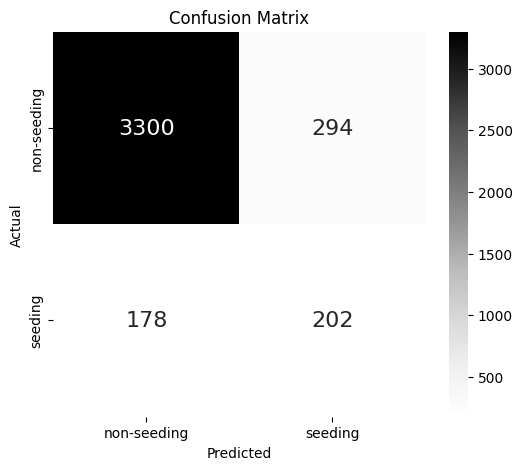

F1 - micro: 0.8812279818822345
F1 - macro: 0.6972225665819541
Accuracy: 0.8812279818822345


In [ ]:
show_predict_result(model, X_test_pad, y_test_label)

In [ ]:
# Siêu tham số
num_filters = 32
filter_sizes = [3, 4, 5]  # kích thước kernel cho các lớp conv
drop = 0.5                # tỷ lệ dropout

# Input
inputs = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32')

# Embedding từ FastText (đã khởi tạo từ trước)
embedding = Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_SEQUENCE_LENGTH,
    trainable=False
)(inputs)

# Convolution + Global Max Pooling cho mỗi kernel size
conv_0 = Conv1D(filters=num_filters, kernel_size=filter_sizes[0], activation='elu')(embedding)
conv_1 = Conv1D(filters=num_filters, kernel_size=filter_sizes[1], activation='elu')(embedding)
conv_2 = Conv1D(filters=num_filters, kernel_size=filter_sizes[2], activation='elu')(embedding)

maxpool_0 = GlobalMaxPooling1D()(conv_0)
maxpool_1 = GlobalMaxPooling1D()(conv_1)
maxpool_2 = GlobalMaxPooling1D()(conv_2)

# Gộp kết quả lại
concatenated_tensor = Concatenate(axis=1)([maxpool_0, maxpool_1, maxpool_2])
flatten = Flatten()(concatenated_tensor)
dropout = Dropout(drop)(flatten)

# Output 2 lớp softmax
output = Dense(units=2, activation='softmax')(dropout)

# Khởi tạo model
model = Model(inputs=inputs, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 300)  │  4,051,500 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 32)    │     28,832 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 97, 32)    │     38,432 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 32)    │     48,032 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 96)        │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96)        │          0 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │        194 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,166,990 (15.90 MB)

 Trainable params: 115,490 (451.13 KB)

 Non-trainable params: 4,051,500 (15.46 MB)

In [ ]:
adam = Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)
model.compile(
    loss='categorical_crossentropy',       # Vì bạn dùng Dense(2, softmax)
    optimizer='adam',
    metrics=['accuracy']
)
model.fit(
    X_train_pad,              # Dữ liệu đầu vào đã padding
    y_train_label,            # Nhãn đã one-hot
    batch_size=256,
    epochs=40,
    validation_data=(X_dev_pad, y_dev_label),  # Nhớ cũng one-hot cho dev
    class_weight={0: 1.0, 1: 1.5},              # (tuỳ chọn) để xử lý mất cân bằng
    callbacks=callbacks,
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.7292 - loss: 0.6822
Epoch 1: val_accuracy improved from -inf to 0.85535, saving model to /content/drive/MyDrive/Seeding_Recognition_Project/model/checkpoints/best_bilstm_model_fasttext.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 35s 438ms/step - accuracy: 0.7296 - loss: 0.6814 - val_accuracy: 0.8553 - val_loss: 0.3977
Epoch 2/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8173 - loss: 0.5254
Epoch 2: val_accuracy improved from 0.85535 to 0.87421, saving model to /content/drive/MyDrive/Seeding_Recognition_Project/model/checkpoints/best_bilstm_model_fasttext.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 30s 426ms/step - accuracy: 0.8173 - loss: 0.5252 - val_accuracy: 0.8742 - val_loss: 0.3421
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8441 - loss: 0.4592
Epoch 3: val_accuracy did not improve from 0.87421
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 428ms/step - accuracy: 0.8441 - loss: 0.4591 - val_accuracy: 0.8736 - val_loss: 0.3308
Epoch 4/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.8598 - loss: 0.4123
Epoch 4: val_accuracy did not improve from 0.87421
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 424ms/step - accuracy: 0.8598 - loss: 0.4123 - val_accuracy: 0.8667 - val_loss: 0.3412
Epoch 5/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.8759 - loss: 0.3753
Epoch 5: val_accuracy did not improve from 0.87421
71/71 ━━━━━━━━━━━━━━━━━━━━ 30s 421ms/step - accuracy: 0.8758 - loss: 0.3752 - val_accuracy: 0.8635 - val_loss: 0.3437
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
CNN_MODEL = os.path.join(MODEL_DIR, 'CNN_fastText.keras')
model.save(CNN_MODEL)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_pad)
y_pred_labels = y_pred.argmax(axis=1)
y_true_labels = y_test.astype(int)

print(confusion_matrix(y_true_labels, y_pred_labels))
print(classification_report(y_true_labels, y_pred_labels, target_names=["non-seeding", "seeding"]))

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
[[3303  291]
 [ 191  189]]
              precision    recall  f1-score   support

 non-seeding       0.95      0.92      0.93      3594
     seeding       0.39      0.50      0.44       380

    accuracy                           0.88      3974
   macro avg       0.67      0.71      0.69      3974
weighted avg       0.89      0.88      0.88      3974



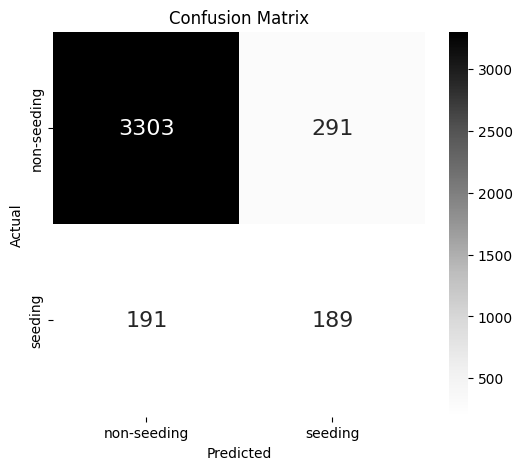

F1 - micro: 0.8787116255661802
F1 - macro: 0.6857663131922935
Accuracy: 0.8787116255661802


In [ ]:
show_predict_result(model, X_test_pad, y_test_label)